# KATL/KDAL Directional Residual Audit V1

This notebook asks whether the V20 regression error direction is predictable in stable subgroups.
It is a diagnostic, not a boundary eligibility rule: every row is retained.

Subgroups are fixed from live-safe forecast context. Signals must have adequate sample sizes, the
same direction in 2023, 2024, and 2025, a minimum per-year effect, and Benjamini-Hochberg adjusted
`q < 0.05`. The untouched 2026 rows only confirm or reject development signals.

Two questions are tested separately:

1. **Residual direction:** is the actual high above or below the point prediction?
2. **Bucket utility:** among decisive actionable cases, would the alternative bucket recover more
   losses than it damages half-up wins?


## Environment


In [1]:
from pathlib import Path
import sys
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.errors import PerformanceWarning

warnings.simplefilter("ignore", PerformanceWarning)
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.calibration.directional_residual_audit import (
    audit_directional_residual_result,
    run_directional_residual_audit,
)
from src.calibration.round_override_v4 import build_utility_override_frame
from src.calibration.v19_bucket import crossfit_ridge_predictions

STATIONS = {
    "KATL": {"pipeline": PROJECT_ROOT / "data/calibration/station_stacking_v20_peak_timing", "peak": True},
    "KDAL": {"pipeline": PROJECT_ROOT / "data/calibration/station_stacking_v20_kdal_no_peak", "peak": False},
}
print(PROJECT_ROOT)


D:\dev\weather-research


## Build honest 2023-2026 point-prediction frames


In [2]:
frames, sources = {}, {}
for station, config in STATIONS.items():
    features = pd.read_csv(config["pipeline"] / f"{station}_features.csv", low_memory=False)
    validation = pd.read_csv(config["pipeline"] / f"{station}_year_split_validation_predictions.csv")
    test = pd.read_csv(config["pipeline"] / f"{station}_year_split_test_predictions.csv")
    development_point = crossfit_ridge_predictions(validation)
    confirmation_point = test.loc[
        test["method"].eq("ridge_stack"),
        ["contract_date", "actual_high_f", "predicted_high_f"],
    ].copy()
    confirmation_point["train_through_year"] = 2025
    confirmation_point["validation_year"] = 2026
    point = pd.concat([development_point, confirmation_point], ignore_index=True)
    base = pd.concat([validation, test], ignore_index=True)
    frame = build_utility_override_frame(
        features, point, base, include_peak_features=config["peak"]
    )
    frames[station] = frame
    sources[station] = {"features": features, "validation": validation, "test": test, "point": point}

pd.DataFrame([
    {
        "station": station,
        "rows": len(frame),
        "start": frame["contract_date"].min().date(),
        "end": frame["contract_date"].max().date(),
        **{f"rows_{year}": int(frame["year"].eq(year).sum()) for year in (2023, 2024, 2025, 2026)},
    }
    for station, frame in frames.items()
])


,station,rows,start,end,rows_2023,rows_2024,rows_2025,rows_2026
0,KATL,1264,2023-01-01,2026-07-12,363,365,364,172
1,KDAL,1261,2023-01-01,2026-06-21,363,364,364,170


## Run fixed subgroup and multiple-testing audit


In [3]:
results = {
    station: run_directional_residual_audit(frame, station_id=station)
    for station, frame in frames.items()
}
yearly_metrics = pd.concat(
    [result["yearly_group_metrics"] for result in results.values()], ignore_index=True
)
residual_stability = pd.concat(
    [result["residual_stability"] for result in results.values()], ignore_index=True
)
utility_stability = pd.concat(
    [result["utility_stability"] for result in results.values()], ignore_index=True
)
print("Audit analysis complete")


Audit analysis complete


## Overall regression residual direction


In [4]:
overall_rows = []
for station, result in results.items():
    frame = result["frame"]
    for year, part in frame.groupby("year"):
        decisive = part.loc[part["decisive_override"]]
        overall_rows.append({
            "station": station,
            "year": int(year),
            "rows": len(part),
            "mean_residual_f": part["residual_f"].mean(),
            "median_residual_f": part["residual_f"].median(),
            "underprediction_rate": part["underprediction_target"].mean(),
            "actionable_rows": int(part["override_actionable"].sum()),
            "decisive_rows": len(decisive),
            "alternative_recovery_share": decisive["recovery_target"].mean(),
        })
overall_metrics = pd.DataFrame(overall_rows)
overall_metrics


,station,year,rows,mean_residual_f,median_residual_f,underprediction_rate,actionable_rows,decisive_rows,alternative_recovery_share
0,KATL,2023,363,-0.738159,-0.709918,0.319559,174,129,0.519380
1,KATL,2024,365,0.297972,0.267560,0.580822,185,141,0.354610
2,KATL,2025,364,-0.032379,-0.018006,0.489011,169,138,0.384058
3,KATL,2026,172,-0.266586,-0.239349,0.430233,89,72,0.472222
4,KDAL,2023,363,-0.677732,-0.519514,0.374656,166,121,0.495868
5,KDAL,2024,364,0.385560,0.465769,0.626374,171,133,0.458647
6,KDAL,2025,364,0.231603,0.191642,0.549451,174,141,0.418440
7,KDAL,2026,170,0.283820,0.152044,0.552941,84,60,0.416667


## Development-stable residual-direction signals


In [5]:
signal_columns = [
    "station", "group_name", "group_value", "development_count", "development_rate",
    "expected_direction", "minimum_year_count", "worst_year_edge", "fdr_q_value",
    "confirmation_count_2026", "confirmation_rate_2026", "confirmation_matches_2026",
    "confirmed_stable_signal",
]
stable_residual = residual_stability.loc[residual_stability["stable_development_signal"]]
stable_residual[signal_columns].sort_values(["station", "fdr_q_value"])


,station,group_name,group_value,development_count,development_rate,expected_direction,minimum_year_count,worst_year_edge,fdr_q_value,confirmation_count_2026,confirmation_rate_2026,confirmation_matches_2026,confirmed_stable_signal
0,KATL,fraction_quarter,"Q1_[0,.25]",261,0.291188,down,75,0.166667,1.094189e-09,43,0.279070,True,True
1,KATL,base_direction,lower_<-0.25,289,0.325260,down,32,0.048387,1.323569e-07,24,0.333333,True,True
2,KATL,half_up_direction,down,511,0.375734,down,166,0.041176,6.644551e-07,80,0.300000,True,True
3,KATL,fraction_x_base_direction,"Q1_[0,.25] | neutral_[-0.25,0.25]",139,0.287770,down,26,0.205882,9.330158e-06,35,0.285714,True,True
4,KATL,month,11,90,0.322222,down,30,0.066667,7.033808e-03,0,NaN,False,False
94,KDAL,fraction_x_base_direction,"Q4_(.75,1) | higher_>0.25",176,0.710227,up,30,0.188525,1.926637e-06,40,0.725000,True,True
95,KDAL,fraction_quarter,"Q4_(.75,1)",263,0.657795,up,84,0.068182,9.424649e-06,48,0.708333,True,True
96,KDAL,recent_bias,negative_<-0.5,266,0.353383,down,30,0.033333,4.095272e-05,0,NaN,False,False
97,KDAL,bias_x_base_direction,"slight_positive_(0,0.5] | higher_>0.25",281,0.626335,up,24,0.089474,3.106594e-04,65,0.461538,False,False
98,KDAL,fraction_x_base_direction,"Q3_(.50,.75] | higher_>0.25",188,0.632979,up,32,0.031250,2.437846e-03,37,0.540541,True,True


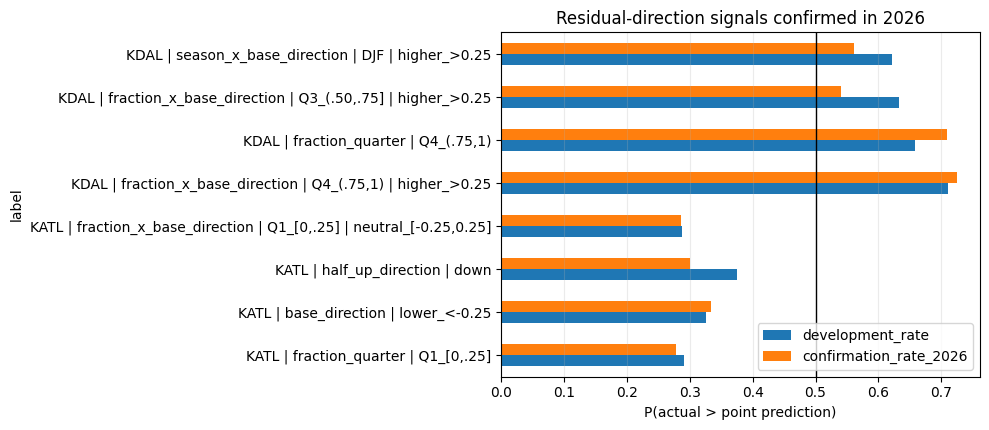

In [6]:
confirmed_residual = stable_residual.loc[stable_residual["confirmed_stable_signal"]]
if not confirmed_residual.empty:
    labels = confirmed_residual["station"] + " | " + confirmed_residual["group_name"] + " | " + confirmed_residual["group_value"]
    plot = confirmed_residual.assign(label=labels).set_index("label")[["development_rate", "confirmation_rate_2026"]]
    ax = plot.plot(kind="barh", figsize=(10, max(4, len(plot) * 0.55)))
    ax.axvline(0.5, color="black", linewidth=1)
    ax.set_xlabel("P(actual > point prediction)")
    ax.set_title("Residual-direction signals confirmed in 2026")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


## Development-stable alternative-bucket utility signals


In [7]:
stable_utility = utility_stability.loc[utility_stability["stable_development_signal"]]
stable_utility[signal_columns].sort_values(["station", "fdr_q_value"])


,station,group_name,group_value,development_count,development_rate,expected_direction,minimum_year_count,worst_year_edge,fdr_q_value,confirmation_count_2026,confirmation_rate_2026,confirmation_matches_2026,confirmed_stable_signal
0,KATL,bucket_support_balance,default_leads_by_2+,200,0.345000,down,59,0.125000,0.001303,42,0.500000,False,False
1,KATL,continuous_advantage,default_>0.10,206,0.359223,down,60,0.073529,0.003030,42,0.547619,False,False


## What survives the untouched 2026 confirmation?


In [8]:
summary = pd.DataFrame([
    {
        "station": station,
        "development_stable_residual_signals": int(result["residual_stability"]["stable_development_signal"].sum()),
        "confirmed_residual_signals_2026": int(result["residual_stability"]["confirmed_stable_signal"].sum()),
        "development_stable_utility_signals": int(result["utility_stability"]["stable_development_signal"].sum()),
        "confirmed_utility_signals_2026": int(result["utility_stability"]["confirmed_stable_signal"].sum()),
    }
    for station, result in results.items()
])
summary


,station,development_stable_residual_signals,confirmed_residual_signals_2026,development_stable_utility_signals,confirmed_utility_signals_2026
0,KATL,5,4,2,0
1,KDAL,6,4,0,0


In [9]:
assert int(summary["confirmed_utility_signals_2026"].sum()) == 0
print(
    "Conclusion: some continuous residual-direction patterns repeat, but no subgroup demonstrates "
    "a development-stable and 2026-confirmed advantage for changing the half-up bucket."
)


Conclusion: some continuous residual-direction patterns repeat, but no subgroup demonstrates a development-stable and 2026-confirmed advantage for changing the half-up bucket.


## Executable integrity audit


In [10]:
audit_report = pd.concat(
    [
        audit_directional_residual_result(frames[station], result).assign(station=station)
        for station, result in results.items()
    ],
    ignore_index=True,
)[["station", "audit", "passed", "detail"]]
display(audit_report)
failed = audit_report.loc[~audit_report["passed"]]
assert failed.empty, failed.to_dict(orient="records")
print(f"All {len(audit_report)} directional residual audits passed")


,station,audit,passed,detail
0,KATL,residual_formula,True,actual minus honest point prediction
1,KATL,direction_target_formula,True,1 means actual exceeds prediction
2,KATL,override_utility_formula,True,recovery minus damage
3,KATL,group_sources_are_target_independent,True,sources=15
4,KATL,diagnostic_groups_do_not_filter_rows,True,rows=1264
5,KATL,development_selection_excludes_2026,True,2026 only confirms selected signals
6,KATL,yearly_metrics_cover_development,True,"years=[np.int64(2023), np.int64(2024), np.int6..."
7,KATL,fdr_values_are_valid,True,Benjamini-Hochberg q-values
8,KATL,fdr_not_below_raw_p,True,multiple-testing correction is conservative
9,KATL,confirmation_requires_minimum_sample,True,confirmed rows pass 2026 sample floor


All 26 directional residual audits passed


## Export audit artifacts


In [11]:
OUTPUT_ROOT = PROJECT_ROOT / "data/calibration/directional_residual_audit_v1"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
overall_metrics.to_csv(OUTPUT_ROOT / "overall_yearly_metrics.csv", index=False)
yearly_metrics.to_csv(OUTPUT_ROOT / "yearly_subgroup_metrics.csv", index=False)
residual_stability.to_csv(OUTPUT_ROOT / "residual_direction_stability.csv", index=False)
utility_stability.to_csv(OUTPUT_ROOT / "alternative_bucket_utility_stability.csv", index=False)
summary.to_csv(OUTPUT_ROOT / "signal_summary.csv", index=False)
audit_report.to_csv(OUTPUT_ROOT / "audit.csv", index=False)
print(OUTPUT_ROOT)


D:\dev\weather-research\data\calibration\directional_residual_audit_v1


## Interpretation contract

A confirmed residual-direction signal means a subgroup tends to be above or below the continuous
point prediction. It does **not** automatically justify changing the 2-degree bucket. Only the
alternative-bucket utility test answers that decision question. No utility subgroup may be used
unless it passes development stability and untouched 2026 confirmation.
